# Churn prediction
### Jimmy Azar

## Introduction

We'll build a classification model for predicting customer churn.

Our data consists of rows representing customers and columns representing features. The labels are in the column "churn" indicating those who unsubscribed within the last month. The features include services that customers signed up for as well as customer account information and demographic information. 

## Data exploration

We load and inspect the data. We also check if the data has any missing values and find out where these instances occur. We remove any rows that have a missing value or attribute.

Finally, we find out how many levels (i.e. unique values) each column has.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data exploration
path_to_file = '../data/churn.txt'
data = pd.read_csv(path_to_file, sep=' ')
print(data.head())
print(data.shape)

rows, cols = np.where(data.isna())
data.loc[rows]

data.dropna(inplace=True)
data.shape

data.nunique()

  customer_id  gender  senior_citizen partner dependents  tenure  \
0  7590-VHVEG  Female               0     Yes         No       1   
1  5575-GNVDE    Male               0      No         No      34   
2  3668-QPYBK    Male               0      No         No       2   
3  7795-CFOCW    Male               0      No         No      45   
4  9237-HQITU  Female               0      No         No       2   

  phone_service    multiple_lines internet_service online_security  ...  \
0            No  No phone service              DSL              No  ...   
1           Yes                No              DSL             Yes  ...   
2           Yes                No              DSL             Yes  ...   
3            No  No phone service              DSL             Yes  ...   
4           Yes                No      Fiber optic              No  ...   

  device_protection tech_support streaming_tv streaming_movies  \
0                No           No           No               No   
1       

customer_id          7032
gender                  2
senior_citizen          2
partner                 2
dependents              2
tenure                 72
phone_service           2
multiple_lines          3
internet_service        3
online_security         3
online_backup           3
device_protection       3
tech_support            3
streaming_tv            3
streaming_movies        3
contract                3
paperless_billing       2
payment_method          4
monthly_charges      1584
total_charges        6530
churn                   2
dtype: int64

### Distribution by gender/internet service/payment method

We check the customer distribution in terms of gender, internet service, and payment method. We create a bar plot for each case.

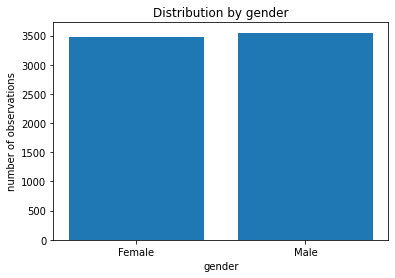

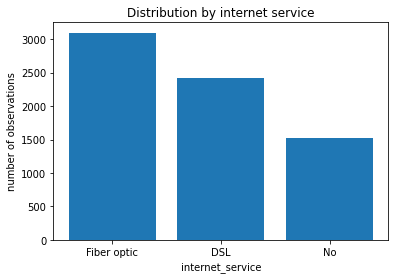

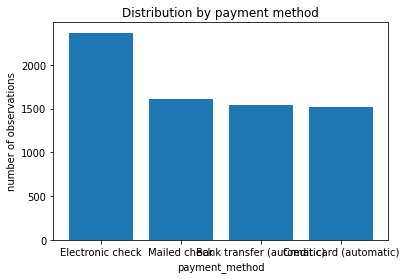

In [2]:
# distribution by gender
values, counts = np.unique(data['gender'], return_counts=True)

plt.bar(values, counts)
plt.xlabel('gender')
plt.ylabel('number of observations')
plt.title('Distribution by gender')
plt.show()

# distribution by internet service
series = data['internet_service'].value_counts()

plt.bar(series.index, series)
plt.xlabel('internet_service')
plt.ylabel('number of observations')
plt.title('Distribution by internet service')
plt.show()

series.idxmax()

# distribution by payment method
series = data['payment_method'].value_counts()

plt.bar(series.index, series)
plt.xlabel('payment_method')
plt.ylabel('number of observations')
plt.title('Distribution by payment method')
plt.show()

series.idxmax();

## Feature transformation

Next, we need to prepare all features for building a predictive model. We can transform two-level categorical features into binary numeric features (with values 0 or 1). For continuous numeric features, we would need to normalize these by deducting the mean and dividing by the standard deviation. This would make the features comparable in scale.

### Binary and continuous features

We identify which features in the dataset are either binary or continuous. We standardize those features that are continuous by removing their mean and dividing by the standard deviation. We also transform the features that are categorical, having two levels, into numeric binary features having values of 0 or 1.

In [3]:
# binary and continuous features
data.nunique()

df_binary = data[["gender", "senior_citizen" ,"partner" ,"dependents", "phone_service","paperless_billing", "churn"]].copy()
df_binary.replace({'Yes':1, 'No':0}, inplace=True)
df_binary.replace({'Male':1, 'Female':0}, inplace=True)

df_continuous = data[['tenure','monthly_charges','total_charges']]
df_continuous = (df_continuous - df_continuous.mean())/df_continuous.std()

df_continuous.describe().loc[['mean','std']] 
df_continuous.std()

df_tx = pd.concat([df_continuous, df_binary], axis=1)
df_tx.head()

,tenure,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,phone_service,paperless_billing,churn
0,-1.280157,-1.161611,-0.994123,0,0,1,0,0,1,0
1,0.064298,-0.260859,-0.173727,1,0,0,0,1,0,0
2,-1.239416,-0.363897,-0.959581,1,0,0,0,1,1,1
3,0.512450,-0.747797,-0.195234,1,0,0,0,0,0,0
4,-1.239416,0.196164,-0.940391,0,0,0,0,1,1,1


### Multi-level categorical features

For the remaining features which are multi-level categorical, we'll apply one-hot-encoding to transform these into numeric values. For example, if one feature can take on 3 values/categories: A, B, and C, then this feature will be transformed into 3 numeric (binary) features, each indicating the presence (1) or absence (0) of a category. Thus a value of A would correspond to $[1,0,0]$, B to $[0,1,0]$, and C to $[0,0,1]$.

Finally, we append the result to the previous data frame consisting of binary and continuous features. 

In [4]:
# multi-level categorical features
df_categorical = data[["multiple_lines","internet_service","online_security","online_backup",
					   "device_protection","tech_support","streaming_tv","streaming_movies",
					   "contract","payment_method"]]

df_tx = pd.concat([pd.get_dummies(df_categorical), df_tx], axis=1)

df_tx.shape

(7032, 41)

## Train/test set

We create a training set, `X_train` along with its labels `y_train`, consisting of 70% of the original data. The remaining 30% goes into the test set, `X_test` and `y_test`. We make sure the sampling is stratified. We're now ready to build a classifier.

In [5]:
# train/test set
from sklearn.model_selection import train_test_split

X = df_tx.drop(['churn'], axis=1)
y = df_tx['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

## Artificial neural network with Keras/Tensorflow

We'll set up a neural network classifier with Keras which is built on top of tensorflow. We build a neural network model with hidden layers containing 16 and 8 neurons with a ReLu (rectified linear unit) activation function. The output layer is a single neuron with a sigmoid activation function that maps into the range $[0,1]$, similar to soft labels. We also select the `adam` algorithm which is a specialized gradient descent algorithm.

In [6]:
from tensorflow import keras

model = keras.Sequential([
keras.layers.Dense(16, kernel_initializer="uniform", activation='relu', input_dim=X_train.shape[1]),  
keras.layers.Dense(8, kernel_initializer="uniform", activation='relu'),
keras.layers.Dense(1, kernel_initializer="uniform", activation='sigmoid')
])

model.summary()

model.compile(optimizer='adam', metrics=['accuracy'], loss='binary_crossentropy')
model.fit(X_train, y_train, validation_split = 0.2, epochs = 40, batch_size = 10, verbose = True)

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 16)                656       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 9         
Total params: 801
Trainable params: 801
Non-trainable params: 0
_________________________________________________________________
Epoch 1/40
394/394 [==============================] - 1s 1ms/step - loss: 0.5165 - accuracy: 0.7595 - val_loss: 0.4429 - val_accuracy: 0.7990
Epoch 2/40
394/394 [==============================] - 0s 974us/step - loss: 0.4249 - accuracy: 0.8011 - val_loss: 0.4272 - val_accuracy: 0.8000
Epoch 3/40
394/394 [==============================] - 0s 969us/step - loss: 0.4215 - accuracy: 0.8044 

We compute the apparent error, i.e. in-sample error, and test error, i.e. out-of-sample error, by comparing the predicted labels with the actual labels found in `y_train` and `y_test`.

In [7]:
error_apparent = 1 - model.evaluate(X_train, y_train)[1] 
error_test = 1- model.evaluate(X_test, y_test)[1]

print(error_apparent)
print(error_test)

model.predict(X_test)

66/66 [==============================] - 0s 677us/step - loss: 0.4212 - accuracy: 0.7986
0.19158875942230225
0.2014217972755432


array([[0.6915691 ],
       [0.78466624],
       [0.41550738],
       ...,
       [0.05030069],
       [0.23236436],
       [0.4224709 ]], dtype=float32)

## Logistic classifier 

In addition, we'll also test the logistic classifier. We predict both soft and hard labels for the test set. Finally, we generate a confusion matrix using the hard labels to assess performance.

In [8]:
# logistic classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression(solver='lbfgs').fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)
model.score(X_test, y_test)

confusion_matrix(y_true=y_test, y_pred=y_pred)
# error_test = (y_test!=y_pred).mean()

array([[1386,  163],
       [ 272,  289]])

## ROC/AUC 

Using the predicted soft labels of the test set, we'll generate an ROC curve and compute the area under the curve (AUC).

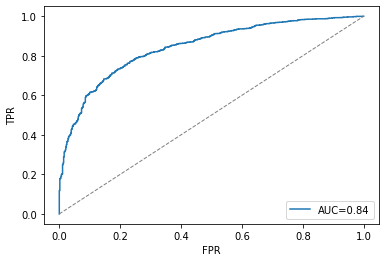

In [9]:
# ROC/AUC using sklearn
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred_prob[:,0], pos_label=0)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC={roc_auc.round(2)}')
plt.plot([0, 1], [0, 1], c='gray', lw=1, linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='lower right')
plt.show()